# Pipeline 1: EasyOCR + LLM (Qwen 3)

This notebook demonstrates the first pipeline combining:
1. **EasyOCR** for text extraction from handwritten nursing notes
2. **Qwen3-8B-(Q4)** for processing and structuring the OCR output
3. **LLM Metrics** for evaluation

## Pipeline Flow
```
Image → EasyOCR → Raw Text → LLM Qwen3-8B-(Q4) → Structured Output → Evaluation
```

## 0. Install Dependencies

## 1. Setup and Imports

In [1]:
import sys
import json
import importlib
import logging
from pathlib import Path

import torch
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from transformers.utils import logging as hf_logging

# Suppress known harmless HF load warnings (e.g., bert-base-multilingual-cased cls.* heads).
hf_logging.set_verbosity_error()
logging.getLogger("transformers.modeling_utils").setLevel(logging.ERROR)

# Resolve project root robustly from either repo root or notebooks/ cwd.
cwd = Path.cwd()
if (cwd / 'src').exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / 'src').exists():
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd.parent.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

# Import our modules
import llm_processing.models as _models_mod
import llm_processing.llm_pipeline as _pipeline_mod
importlib.reload(_models_mod)
importlib.reload(_pipeline_mod)

from llm_processing.llm_pipeline import LLMPipeline
from llm_processing.prompts import get_prompt, PROMPTS
from evaluation.metrics import calculate_all_metrics
from evaluation.llm_metrics import (
    calculate_rouge_scores,
    calculate_bertscore,
    calculate_information_preservation,
    extract_medical_terms
)

print("✓ Imports successful")
print(f"  PROJECT_ROOT = {PROJECT_ROOT}")
print(f"  Torch: {torch.__version__}")
print("  HF model-loading warnings for known head-mismatch are suppressed")

/home/bashar/bachelor-thesis-nursing-agents/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Imports successful
  PROJECT_ROOT = /home/bashar/bachelor-thesis-nursing-agents
  Torch: 2.10.0+cu128
  HF model-loading warnings for known head-mismatch are suppressed


## 2. Initialize EasyOCR

In [2]:
import easyocr

# Initialize EasyOCR reader for German
print("Initializing EasyOCR reader for German...")
reader = easyocr.Reader(['de'], gpu=True)
print("✓ EasyOCR reader initialized")

Initializing EasyOCR reader for German...
✓ EasyOCR reader initialized


## 3. Load Sample Image and Ground Truth

In [3]:

# Load test set
test_set_path = PROJECT_ROOT / 'data' / 'test_set_500.json'
with open(test_set_path, 'r', encoding='utf-8') as f:
    test_set = json.load(f)

# Select first sample
sample = test_set['samples'][117]
print(f"Sample ID: {sample['sample_id']}")
print(f"Font: {sample['font']}")
print(f"Scenario: {sample['scenario']}")

# Load image
image_path = PROJECT_ROOT / sample['image_path']
image = Image.open(image_path)

# Load ground truth label
label_path = PROJECT_ROOT / sample['label_path']
with open(label_path, 'r', encoding='utf-8') as f:
    ground_truth = json.load(f)

# Load reference_summary from scenarios.json (gold reference for ROUGE / BLEU)
scenarios_path = PROJECT_ROOT / 'data' / 'synthetic' / 'scenarios.json'
with open(scenarios_path, 'r', encoding='utf-8') as f:
    scenarios = json.load(f)

scenario_lookup = {s['patient']: s for s in scenarios}
current_scenario = scenario_lookup.get(sample['scenario'], {})
reference_summary = current_scenario.get('reference_summary', '')

if not reference_summary:
    print(f"⚠ No reference_summary found for scenario '{sample['scenario']}'")
else:
    print(f"✓ Reference summary loaded ({len(reference_summary)} chars)")

print(f"\nImage size: {image.size}")
print(f"Text length: {len(ground_truth['full_text'])} characters")


Sample ID: sample_0154
Font: HomemadeApple-Regular
Scenario: Elisabeth Weber
✓ Reference summary loaded (798 chars)

Image size: (1240, 1754)
Text length: 1291 characters


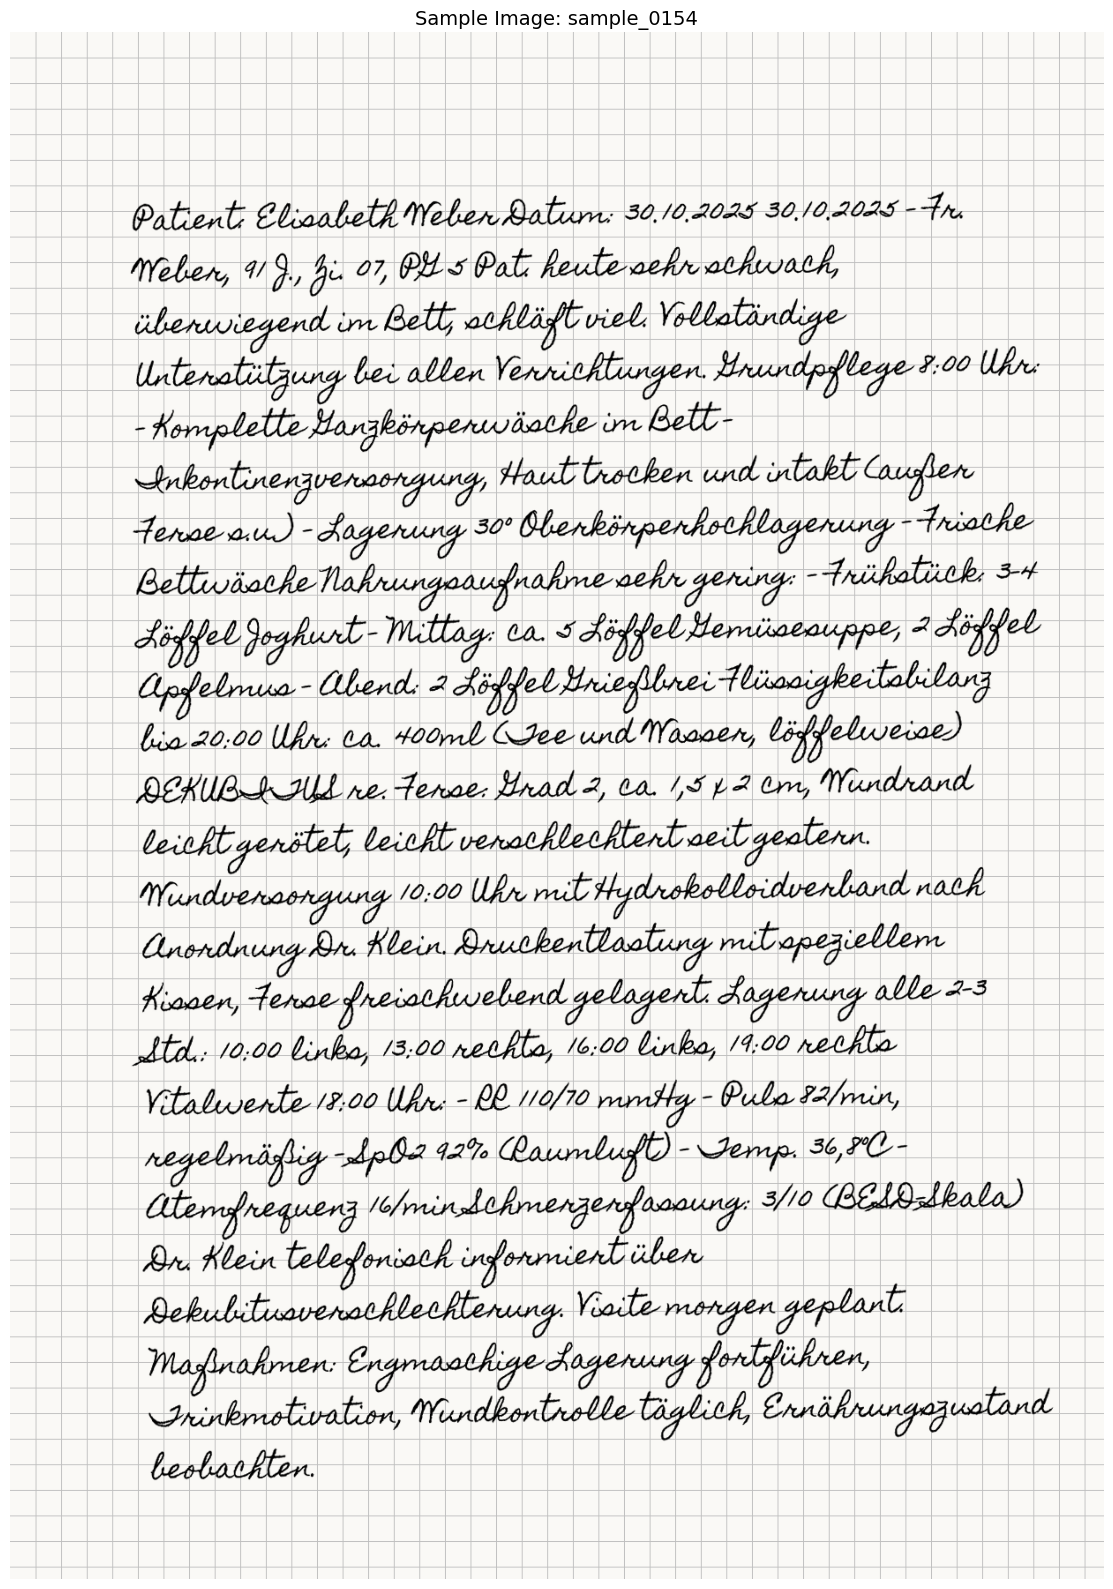

In [4]:
# Display the image
plt.figure(figsize=(12, 16))
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.title(f"Sample Image: {sample['sample_id']}", fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
# Display ground truth
print("="*80)
print("GROUND TRUTH TEXT:")
print("="*80)
print(ground_truth['original_notes'])
print("="*80)

GROUND TRUTH TEXT:
30.10.2025 - Fr. Weber, 91 J., Zi. 07, PG 5

Pat. heute sehr schwach, überwiegend im Bett, schläft viel. Vollständige Unterstützung bei allen Verrichtungen.

Grundpflege 8:00 Uhr:
- Komplette Ganzkörperwäsche im Bett
- Inkontinenzversorgung, Haut trocken und intakt (außer Ferse s.u.)
- Lagerung 30° Oberkörperhochlagerung
- Frische Bettwäsche

Nahrungsaufnahme sehr gering:
- Frühstück: 3-4 Löffel Joghurt
- Mittag: ca. 5 Löffel Gemüsesuppe, 2 Löffel Apfelmus
- Abend: 2 Löffel Grießbrei

Flüssigkeitsbilanz bis 20:00 Uhr: ca. 400ml (Tee und Wasser, löffelweise)

DEKUBITUS re. Ferse:
Grad 2, ca. 1,5 x 2 cm, Wundrand leicht gerötet, leicht verschlechtert seit gestern. Wundversorgung 10:00 Uhr mit Hydrokolloidverband nach Anordnung Dr. Klein. Druckentlastung mit speziellem Kissen, Ferse freischwebend gelagert.

Lagerung alle 2-3 Std.: 10:00 links, 13:00 rechts, 16:00 links, 19:00 rechts

Vitalwerte 18:00 Uhr:
- RR 110/70 mmHg
- Puls 82/min, regelmäßig
- SpO2 92% (Raumluft)


## 4. Run EasyOCR

In [6]:
# Run OCR
print("Running EasyOCR...")
ocr_results = reader.readtext(str(image_path))

# Extract text from results
# ocr_text = ' '.join([text for (bbox, text, conf) in ocr_results])
ocr_txt = '\n'.join([text for (_, text, _) in ocr_results])

print(f"✓ OCR completed")
print(f"Detected {len(ocr_results)} text regions")
print(f"Total OCR text length: {len(ocr_txt)} characters")

Running EasyOCR...
✓ OCR completed
Detected 69 text regions
Total OCR text length: 1187 characters


In [7]:
# Display OCR output with confidence scores
print("="*80)
print("EasyOCR OUTPUT (with confidence):")
print("="*80)
for i, (bbox, text, conf) in enumerate(ocr_results[:10], 1):  # Show first 10
    print(f"{i:2d}. [{conf:.3f}] {text}")
if len(ocr_results) > 10:
    print(f"... and {len(ocr_results) - 10} more regions")
print("="*80)

EasyOCR OUTPUT (with confidence):
 1. [0.180] Patent Eliaaleth 'eben Batum: 30./0.2025 30./0.2025
 2. [0.074] 3n
 3. [0.186] MYelet
 4. [0.587] 9/
 5. [0.148] 8, Ji 07, PH s Pat Reute aekn achwach
 6. [0.741] ületuiegend
 7. [0.191] im
 8. [0.371] Bett; ackläftviel
 9. [0.356] Uteratutgung bei ablen
10. [0.122] Yenuchtargen Hnundf fVege
... and 59 more regions


In [8]:
# Display full OCR text
print("="*80)
print("FULL OCR TEXT:")
print("="*80)
print(ocr_txt)
print("="*80)

FULL OCR TEXT:
Patent Eliaaleth 'eben Batum: 30./0.2025 30./0.2025
3n
MYelet
9/
8, Ji 07, PH s Pat Reute aekn achwach
ületuiegend
im
Bett; ackläftviel
Uteratutgung bei ablen
Yenuchtargen Hnundf fVege
{,00 URr
Xomplettejlangkötpenuuäache imn Bett
nbontsengvenaorgugp Hauttocben ud itakt Cauflec
fenoeau))
'dagenug
30
OtenböspenRochlagenurg
#niache
BettiäacheZlahuungaavfnahmeaehvgenig
fnükatiicl 3 4
9 ghunt
ca
4iffelHemüaeauffe ? #iffel
apfelmua
Cuend:
aiffelxnefhnei Flüaaigkeitahilan
Bia20.00 UAns ca
HoomlQeeund aaaer
laf ebueiae)
@exue4-E
ne fetae Hnad 2,
6a /,3 } 2 Lm MYundzand
leiclt
leichtvetacAlechtertaet
ffandvenaotqurg
10.00
Ukn mit
"Hudvokolloidoenband nach
A* Xlein
Ancbentiaatiug mtapeziellem
Xiaaen Yetae
'aelagent {ageng alle
2-3
Jatd: 10,00 linba 13,00 hechta
16;00
Cinba
/9,00 nechta
Ystalwente /3,00 UAr
p@ /0/70
Pula {a/min
negelmäfa -Ipaa 929 CPaumlyft)
36,PC
aterfnequerg "lmin Jckmergenfnaaurg
3/10 (PgJOJbala)
A* Klein telefeniack i fonmientülen
Bekultuaverachlechtenung Yiai

## 5. Initialize LLM Pipeline (Qwen 3)

In [9]:
# Check available prompts
print("Available prompts:")
print("="*80)
for name, prompt in PROMPTS.items():
    print(f"\n{name}:")
    print(f"  {prompt['description']}")
print("="*80)

Available prompts:

nursing_prompt:
  Summarize noisy OCR nursing notes and extract exact key features

nursing_summary:
  Summarize noisy OCR nursing notes and extract exact key features

critical_info_extraction:
  Extract critical medical information only

care_plan_generation:
  Generate a care plan based on the notes

risk_assessment:
  Assess patient risks from nursing notes

simple_summary:
  Simple one-paragraph summary

VLM_prompt:
  End-to-End OCR and summarization of nursing notes from images

VLM_prompt_v2:
  End-to-End summarization of nursing notes from images


In [10]:
nursing_summary_prompt = get_prompt('nursing_summary')
print("Selected prompt for nursing summary:")
nursing_summary_prompt

Selected prompt for nursing summary:


{'name': 'Nursing Summary',
 'description': 'Summarize noisy OCR nursing notes and extract exact key features',
 'system': 'Du bist ein medizinischer Assistent, spezialisiert auf Pflegedokumentation und die Fehlerkorrektur von fehlerhaften OCR-Texten. \nDeine Aufgabe ist es, unsaubere Pflegenotizen zu lesen, OCR-Tippfehler implizit zu korrigieren und die klinischen Fakten strikt beizubehalten, ohne neue Informationen zu erfinden.',
 'task': "Analysiere den folgenden Text, der aus einer fehlerhaften OCR-Texterkennung stammt. \nFasse den Text zusammen und extrahiere die wichtigsten Merkmale.\n\nWICHTIGE REGELN:\n- Bewahre ALLE medizinischen Fachbegriffe, Vitalwerte (z.B. Puls, Atemfrequenz) und Pflegemaßnahmen (z.B. Wundversorgung, Dekubitus).\n- Wenn ein Wort durch OCR falsch geschrieben ist (z.B. 'D3kubitus'), korrigiere es stillschweigend zu 'Dekubitus'.\n- Erfinde KEINE allgemeinen Begriffe wie 'Behandlung' oder 'Körperpflege', wenn sie nicht im Text stehen.\n- Bleibe zu 100% bei den

In [11]:
# Initialize LLM pipeline with Qwen3-8B (4-bit quantisation via bitsandbytes)
# Qwen3-8B BF16 = ~16 GB → does NOT fit on RTX 3060 12 GB
# With load_in_4bit=True: ~5–6 GB → fits comfortably ✓
# Thinking mode OFF: not needed for text structuring, keeps generation fast

pipeline = LLMPipeline(
    model_name='qwen3-8b',        # → Qwen/Qwen3-8B (base full precision, quantised at load)
    prompt_name='nursing_summary',
    device='cuda',
    load_in_4bit=True,             # bitsandbytes 4-bit → ~5–6 GB VRAM on RTX 3060 ✓
    max_new_tokens=1024,           # Enough for detailed nursing summaries
    temperature=0.0,               # Deterministic — reproducible results for thesis
    do_sample=False,               # Must be False when temperature=0.0
    enable_thinking=False,         # Thinking OFF — fast instruct mode
)

print("\n✓ LLM Pipeline initialized and ready")


Loading weights: 100%|██████████| 399/399 [00:05<00:00, 67.18it/s] 



✓ LLM Pipeline initialized and ready


## 6. Process OCR Text with LLM

In [12]:
# Process the OCR text with LLM
print("Processing OCR text with Qwen3-8B (4-bit)...")
llm_output = pipeline.process_text(ocr_txt)
print("✓ LLM processing completed")


Processing OCR text with Qwen3-8B (4-bit)...
✓ LLM processing completed


In [13]:
# Display LLM output
print("="*80)
print("LLM OUTPUT (Qwen3-8B 4-bit - Nursing Summary):")
print("="*80)
print(llm_output)
print("="*80)


LLM OUTPUT (Qwen3-8B 4-bit - Nursing Summary):
1. **Zusammenfassung**:  
Die Pflegedokumentation beschreibt eine Patientin mit Dekubitus, Wundversorgung, Atemnot, Atemfrequenz und Pulswerten. Es wird eine Wundversorgung im Gesäßbereich dokumentiert, eine Atemnot mit erhöhter Atemfrequenz, sowie eine Blutdruckmessung und eine körperliche Bettnachstellung erwähnt. Zudem sind Pflegemaßnahmen wie die Anwendung von Schmerzmitteln und die Dokumentation von Vitalzeichen enthalten.

2. **Wichtige Merkmale**:  
- **Dekubitus** im Gesäßbereich  
- **Wundversorgung** im Gesäßbereich  
- **Atemnot** (Atemfrequenz 30–35/min)  
- **Puls** 92–93 Schläge/min  
- **Blutdruck** 100/70 mmHg  
- **Atemfrequenz** 30–35/min  
- **Pflegemaßnahme**: Schmerzmittel (Painkiller)  
- **Körperposition**: Bettnachstellung  
- **Dokumentation**: Vitalzeiten (10:00 Uhr)  
- **Bewusstsein**: Vollständig  
- **Pflegebedarf**: Wundversorgung, Dekubitusprävention


## 7. Evaluate LLM Output

In [14]:

# Calculate ROUGE scores (LLM output vs reference_summary — summary-to-summary)
rouge_scores = calculate_rouge_scores(
    reference=reference_summary,
    hypothesis=llm_output
)

print("ROUGE Scores (LLM output vs Reference Summary):")
print("="*80)
print(f"ROUGE-1:")
print(f"  Precision: {rouge_scores['rouge1_precision']:.2f}%")
print(f"  Recall:    {rouge_scores['rouge1_recall']:.2f}%")
print(f"  F1:        {rouge_scores['rouge1_f1']:.2f}%")
print(f"\nROUGE-2:")
print(f"  Precision: {rouge_scores['rouge2_precision']:.2f}%")
print(f"  Recall:    {rouge_scores['rouge2_recall']:.2f}%")
print(f"  F1:        {rouge_scores['rouge2_f1']:.2f}%")
print(f"\nROUGE-L:")
print(f"  Precision: {rouge_scores['rougeL_precision']:.2f}%")
print(f"  Recall:    {rouge_scores['rougeL_recall']:.2f}%")
print(f"  F1:        {rouge_scores['rougeL_f1']:.2f}%")
print("="*80)


ROUGE Scores (LLM output vs Reference Summary):
ROUGE-1:
  Precision: 19.61%
  Recall:    16.67%
  F1:        18.02%

ROUGE-2:
  Precision: 3.96%
  Recall:    3.36%
  F1:        3.64%

ROUGE-L:
  Precision: 11.76%
  Recall:    10.00%
  F1:        10.81%


ROUGE Scores (LLM output vs Reference Summary):
================================================================================
ROUGE-1:
  Precision: 19.42%
  Recall:    16.67%
  F1:        17.94%

ROUGE-2:
  Precision: 5.88%
  Recall:    5.04%
  F1:        5.43%

ROUGE-L:
  Precision: 15.53%
  Recall:    13.33%
  F1:        14.35%
================================================================================

ROUGE Scores (LLM output vs Reference Summary):
================================================================================
ROUGE-1:
  Precision: 23.73%
  Recall:    23.33%
  F1:        23.53%

ROUGE-2:
  Precision: 5.98%
  Recall:    5.88%
  F1:        5.93%

ROUGE-L:
  Precision: 14.41%
  Recall:    14.17%
  F1:        14.29%
================================================================================

In [17]:

# Calculate BERTScore (LLM output vs reference_summary)
# Uses bert-base-multilingual-cased for German support
bert_scores = calculate_bertscore(
    reference=reference_summary,
    hypothesis=llm_output
)

print("BERTScore (LLM output vs Reference Summary):")
print("="*80)
print(f"  Precision: {bert_scores['bertscore_precision']:.2f}%")
print(f"  Recall:    {bert_scores['bertscore_recall']:.2f}%")
print(f"  F1:        {bert_scores['bertscore_f1']:.2f}%")
print("="*80)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2513.86it/s]


BERTScore (LLM output vs Reference Summary):
  Precision: 24.95%
  Recall:    15.57%
  F1:        20.25%


BERTScore (LLM output vs Reference Summary):
================================================================================
  Precision: 17.39%
  Recall:    15.56%
  F1:        16.60%
================================================================================

In [18]:

# Medical term preservation (reference_summary vs LLM output)
medical_terms_ref = extract_medical_terms(reference_summary)
medical_terms_hyp = extract_medical_terms(llm_output)

preservation = calculate_information_preservation(
    reference=reference_summary,
    summary=llm_output
)

# Calculate missing and extra terms
missing_terms = medical_terms_ref - medical_terms_hyp
extra_terms = medical_terms_hyp - medical_terms_ref

print("\nMedical Term Preservation (vs Reference Summary):")
print("="*80)
print(f"Terms in reference:  {preservation['terms_in_reference']}")
print(f"Terms in summary:    {preservation['terms_in_summary']}")
print(f"Terms preserved:     {preservation['terms_preserved']}")
print(f"Precision:           {preservation['medical_term_precision']:.2f}%")
print(f"Recall:              {preservation['medical_term_recall']:.2f}%")
print(f"F1:                  {preservation['medical_term_f1']:.2f}%")

if missing_terms:
    print(f"\nMissing terms ({len(missing_terms)}):")
    for term in sorted(missing_terms)[:10]:
        print(f"  - {term}")
    if len(missing_terms) > 10:
        print(f"  ... and {len(missing_terms) - 10} more")

if extra_terms:
    print(f"\nExtra terms ({len(extra_terms)}):")
    for term in sorted(extra_terms)[:10]:
        print(f"  - {term}")
    if len(extra_terms) > 10:
        print(f"  ... and {len(extra_terms) - 10} more")

print("="*80)



Medical Term Preservation (vs Reference Summary):
Terms in reference:  6
Terms in summary:    5
Terms preserved:     1
Precision:           20.00%
Recall:              16.67%
F1:                  18.18%

Missing terms (5):
  - bettlägerig
  - dekubitus
  - lagerung
  - nahrungsaufnahme
  - schmerz

Extra terms (4):
  - atemfrequenz
  - flüssigkeitsaufnahme
  - patient
  - temperatur


## 8. Visualize Results

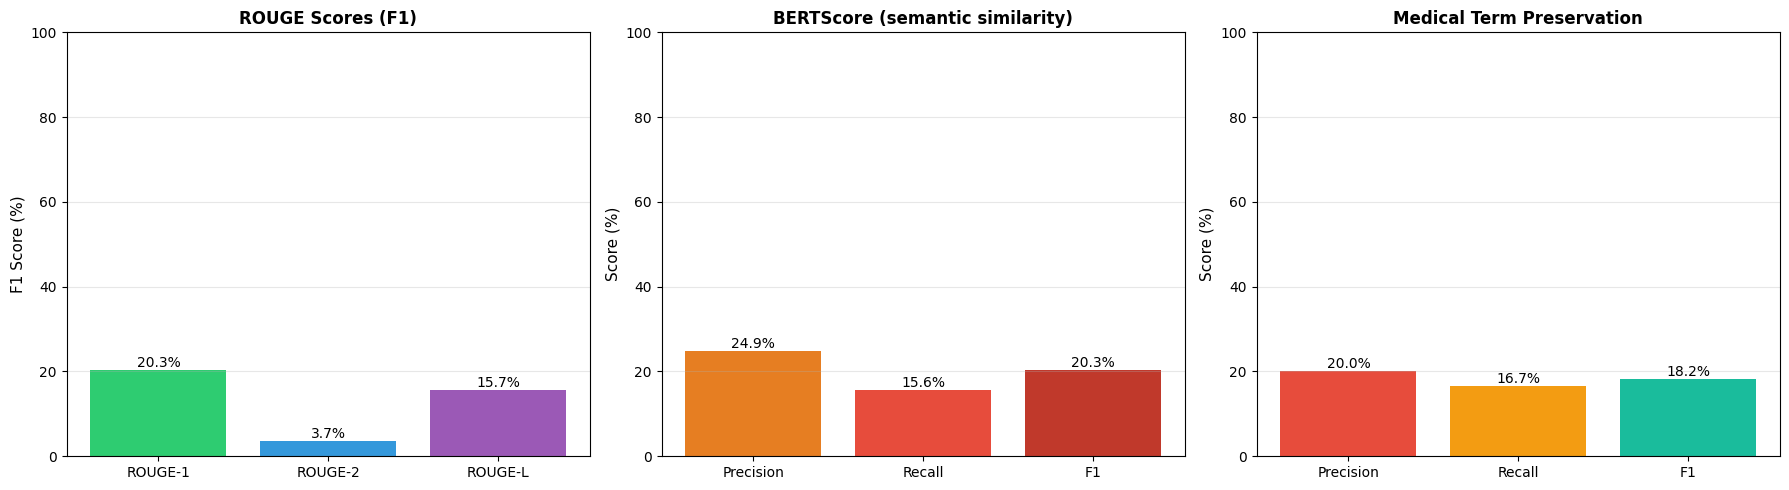

In [19]:
# Create visualization of metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROUGE F1 scores
ax1 = axes[0]
rouge_metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
f1_scores = [
    rouge_scores['rouge1_f1'],
    rouge_scores['rouge2_f1'],
    rouge_scores['rougeL_f1']
]
bars1 = ax1.bar(rouge_metrics, f1_scores, color=['#2ecc71', '#3498db', '#9b59b6'])
ax1.set_ylabel('F1 Score (%)', fontsize=11)
ax1.set_title('ROUGE Scores (F1)', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 100)
ax1.grid(axis='y', alpha=0.3)
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

# BERTScore
ax2 = axes[1]
bert_labels = ['Precision', 'Recall', 'F1']
bert_vals = [
    bert_scores['bertscore_precision'],
    bert_scores['bertscore_recall'],
    bert_scores['bertscore_f1'],
]
bars2 = ax2.bar(bert_labels, bert_vals, color=['#e67e22', '#e74c3c', '#c0392b'])
ax2.set_ylabel('Score (%)', fontsize=11)
ax2.set_title('BERTScore (semantic similarity)', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 100)
ax2.grid(axis='y', alpha=0.3)
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

# Medical term preservation
ax3 = axes[2]
preservation_metrics = ['Precision', 'Recall', 'F1']
preservation_scores = [
    preservation['medical_term_precision'],
    preservation['medical_term_recall'],
    preservation['medical_term_f1']
]
bars3 = ax3.bar(preservation_metrics, preservation_scores, color=['#e74c3c', '#f39c12', '#1abc9c'])
ax3.set_ylabel('Score (%)', fontsize=11)
ax3.set_title('Medical Term Preservation', fontsize=12, fontweight='bold')
ax3.set_ylim(0, 100)
ax3.grid(axis='y', alpha=0.3)
for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


## 9. Summary

In [17]:

# Create summary
summary = f"""
{'='*80}
PIPELINE SUMMARY: EasyOCR + Qwen3-8B (4-bit quantisation)
{'='*80}

Sample: {sample['sample_id']}
Font: {sample['font']}
Scenario: {sample['scenario']}

OCR Performance:
  - Detected regions: {len(ocr_results)}
  - OCR text length: {len(ocr_text)} chars
  - Ground truth length: {len(ground_truth['full_text'])} chars

LLM Performance (Qwen3-8B, bitsandbytes 4-bit):
  - Model: {pipeline.model_name}
  - Prompt: {pipeline.prompt_name}
  - Output length: {len(llm_output)} chars

Reference:
  - Reference summary length: {len(reference_summary)} chars
  - Source: scenarios.json → reference_summary

Evaluation Metrics (LLM output vs reference_summary):
  ROUGE-1 F1:          {rouge_scores['rouge1_f1']:.2f}%
  ROUGE-2 F1:          {rouge_scores['rouge2_f1']:.2f}%
  ROUGE-L F1:          {rouge_scores['rougeL_f1']:.2f}%
  BERTScore F1:        {bert_scores['bertscore_f1']:.2f}%
    Precision:         {bert_scores['bertscore_precision']:.2f}%
    Recall:            {bert_scores['bertscore_recall']:.2f}%

  Medical Terms:
    Precision:         {preservation['medical_term_precision']:.2f}%
    Recall:            {preservation['medical_term_recall']:.2f}%
    F1:                {preservation['medical_term_f1']:.2f}%

{'='*80}
"""

print(summary)



PIPELINE SUMMARY: EasyOCR + Qwen3-8B (4-bit quantisation)

Sample: sample_0154
Font: HomemadeApple-Regular
Scenario: Elisabeth Weber

OCR Performance:
  - Detected regions: 69
  - OCR text length: 1187 chars
  - Ground truth length: 1291 chars

LLM Performance (Qwen3-8B, bitsandbytes 4-bit):
  - Model: Qwen/Qwen3-8B
  - Prompt: nursing_summary
  - Output length: 1013 chars

Reference:
  - Reference summary length: 798 chars
  - Source: scenarios.json → reference_summary

Evaluation Metrics (LLM output vs reference_summary):
  ROUGE-1 F1:          23.53%
  ROUGE-2 F1:          5.93%
  ROUGE-L F1:          14.29%
  BERTScore F1:        16.60%
    Precision:         17.39%
    Recall:            15.56%

  Medical Terms:
    Precision:         25.00%
    Recall:            33.33%
    F1:                28.57%




## 10. Batch Evaluation — N48 Balanced Set

Same deterministic 48-sample set used across all pipeline notebooks for fair comparison:
- **All 24 fonts** represented (full font coverage)
- **Balanced text lengths** — short (<=300 chars), medium (301-700), long (>700)
- **All paper types, colours, and writing styles** covered

N48 set: 48 samples  (24 fonts · balanced text lengths)



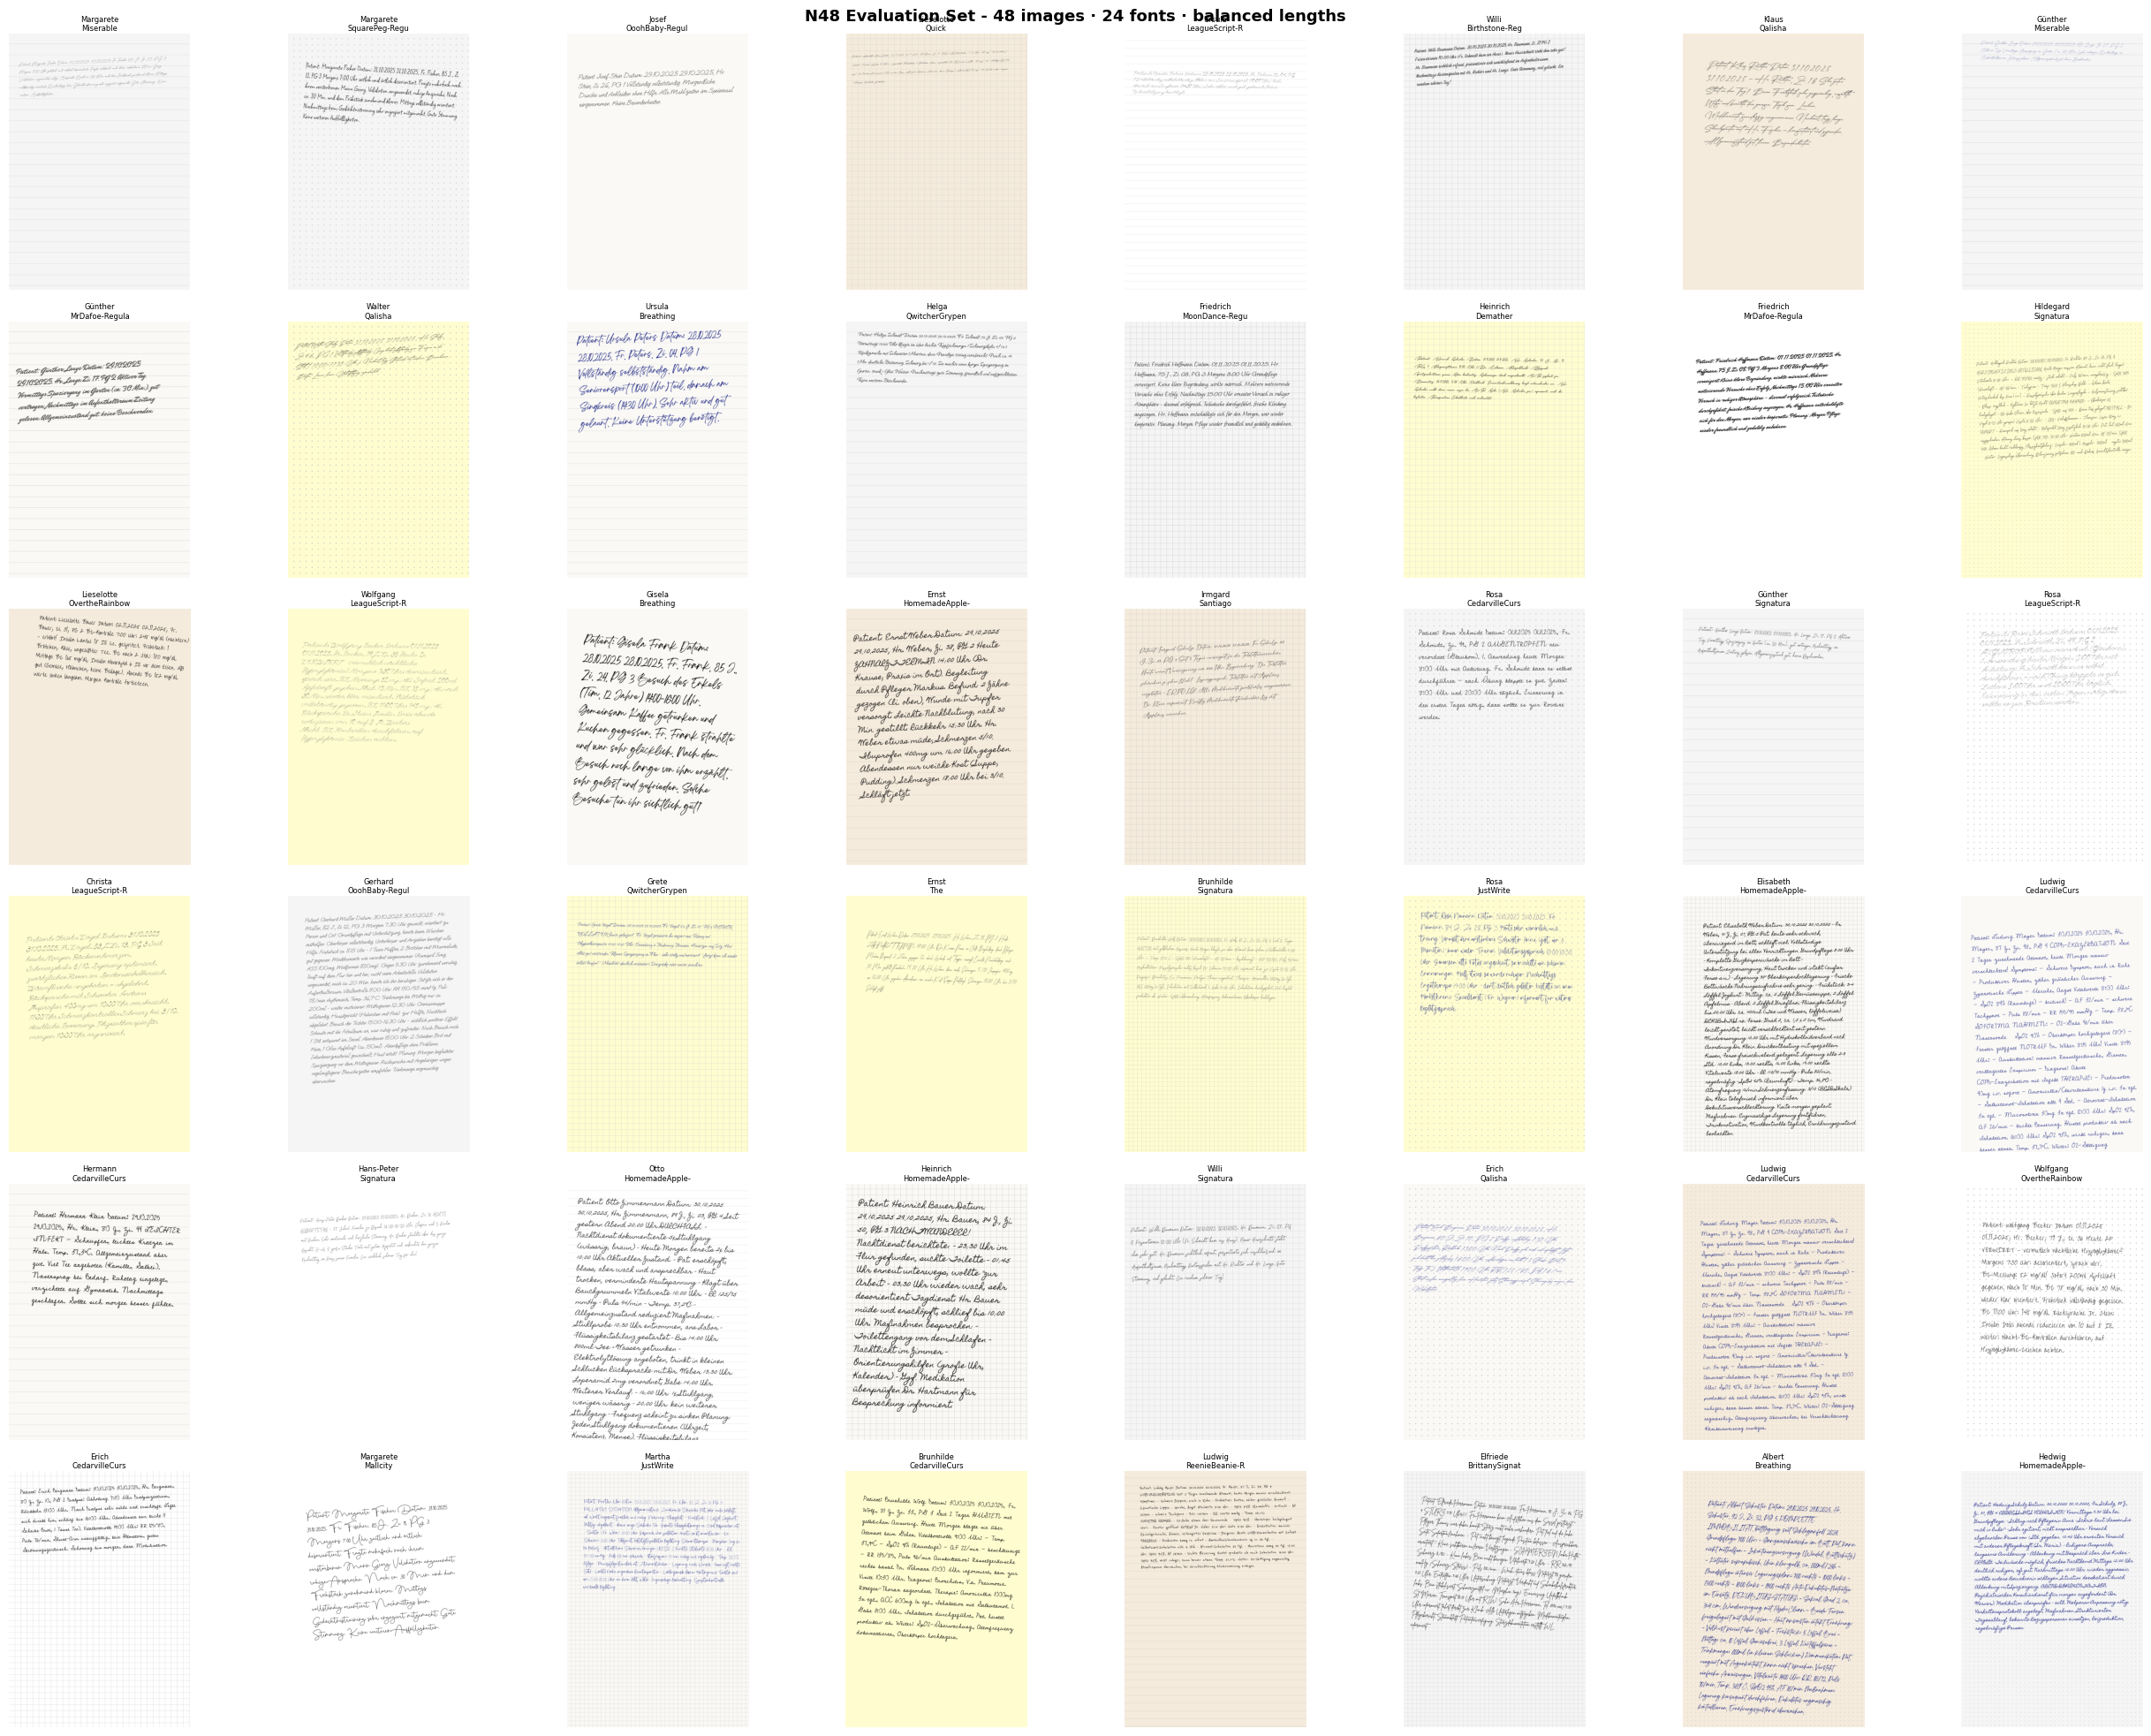

✓ 48 images previewed — run the next cell to start the pipeline


In [18]:
# -- N48 Balanced Evaluation Set ----------------------------------------------
# 48 images: all 24 fonts covered, balanced across short/medium/long text lengths.
import os

SYNTHETIC_IMAGES = PROJECT_ROOT / 'data' / 'synthetic' / 'output' / 'images'
SYNTHETIC_LABELS = PROJECT_ROOT / 'data' / 'synthetic' / 'output' / 'labels'
N48_DIR          = PROJECT_ROOT / 'data' / 'N30'

N48_SAMPLE_IDS = sorted(p.stem for p in N48_DIR.glob('*.png'))
print(f"N48 set: {len(N48_SAMPLE_IDS)} samples  (24 fonts · balanced text lengths)\n")

# Build metadata list directly from label files (no test_set indexing needed)
n48_samples_meta = []
for sid in N48_SAMPLE_IDS:
    lbl_path = SYNTHETIC_LABELS / f"{sid}.json"
    with open(lbl_path, encoding='utf-8') as _f:
        lbl = json.load(_f)
    font_file = os.path.basename(lbl['generation_parameters'].get('font_path', ''))
    n48_samples_meta.append({
        'sample_id':  sid,
        'image_path': SYNTHETIC_IMAGES / f"{sid}.png",
        'label_path': str(lbl_path),
        'font':       os.path.splitext(font_file)[0],
        'scenario':   lbl.get('patient', ''),
    })

# -- Preview grid --------------------------------------------------------------
n_cols, n_rows = 8, 6
fig, axes = plt.subplots(n_rows, n_cols, figsize=(26, 20))
fig.suptitle(
    f"N48 Evaluation Set - {len(N48_SAMPLE_IDS)} images · 24 fonts · balanced lengths",
    fontsize=13, fontweight='bold')

for ax, meta in zip(axes.flat, n48_samples_meta):
    img = Image.open(meta['image_path'])
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    font_short    = meta['font'].split()[0][:14]
    patient_first = meta['scenario'].split()[0]
    ax.set_title(f"{patient_first}\n{font_short}", fontsize=6, pad=2)

for ax in axes.flat[len(n48_samples_meta):]:
    ax.axis('off')

plt.tight_layout()
plt.show()
print(f"✓ {len(N48_SAMPLE_IDS)} images previewed — run the next cell to start the pipeline")

In [19]:
import pandas as pd

# n48_samples_meta is defined in the preview cell above.

print(f"N48 batch: {len(n48_samples_meta)} samples  "
      f"(24 fonts, balanced text lengths)\n")
print(f"{'#':>3}  {'Sample ID':<22} {'R1-F1':>7} {'BERT-F1':>9} {'Med-F1':>8}")
print("-" * 55)

batch_results = []

for i, meta in enumerate(n48_samples_meta):
    curr_scenario = scenario_lookup.get(meta['scenario'], {})
    ref_summary   = curr_scenario.get('reference_summary', '')

    if not ref_summary:
        print(f"{i+1:3d}  {meta['sample_id']:<22}  SKIPPED — no reference_summary")
        continue

    # -- OCR ------------------------------------------------------------------
    ocr_res = reader.readtext(str(meta['image_path']))
    ocr_txt = ' '.join([text for (_, text, _) in ocr_res])

    # -- LLM (Qwen3-8B 4-bit) -------------------------------------------------
    try:
        llm_out = pipeline.process_text(ocr_txt)
    except Exception as e:
        print(f"{i+1:3d}  {meta['sample_id']:<22}  LLM ERROR: {e}")
        continue

    # -- Metrics --------------------------------------------------------------
    rouge = calculate_rouge_scores(reference=ref_summary, hypothesis=llm_out)
    bert  = calculate_bertscore(reference=ref_summary, hypothesis=llm_out)
    pres  = calculate_information_preservation(reference=ref_summary, summary=llm_out)

    batch_results.append({
        'sample_id': meta['sample_id'],
        'font':      meta['font'],
        'scenario':  meta['scenario'],
        **rouge,
        **bert,
        **pres,
    })

    print(f"{i+1:3d}  {meta['sample_id']:<22} "
          f"{rouge['rouge1_f1']:>6.1f}% "
          f"{bert['bertscore_f1']:>8.1f}% "
          f"{pres['medical_term_f1']:>7.1f}%")

print(f"\n✓ Batch complete — {len(batch_results)}/{len(n48_samples_meta)} samples processed")

N48 batch: 48 samples  (24 fonts, balanced text lengths)

  #  Sample ID                R1-F1   BERT-F1   Med-F1
-------------------------------------------------------


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2866.54it/s]


  1  sample_0002               9.8%      3.5%     0.0%


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2283.85it/s]


  2  sample_0004              28.4%     23.5%    25.0%


...

 46  sample_0865              12.4%      3.4%    22.2%


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2612.89it/s]


 47  sample_0869              15.3%      8.7%    25.0%


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2732.73it/s]


 48  sample_0883               8.4%      3.2%   100.0%

✓ Batch complete — 48/48 samples processed


In [20]:
if not batch_results:
    print("No results to aggregate — all samples were skipped or errored.")
else:
    df = pd.DataFrame(batch_results)

    METRIC_COLS = [
        ('ROUGE-1 F1',          'rouge1_f1'),
        ('ROUGE-2 F1',          'rouge2_f1'),
        ('ROUGE-L F1',          'rougeL_f1'),
        ('BERTScore Precision', 'bertscore_precision'),
        ('BERTScore Recall',    'bertscore_recall'),
        ('BERTScore F1',        'bertscore_f1'),
        ('Med.Term Precision',  'medical_term_precision'),
        ('Med.Term Recall',     'medical_term_recall'),
        ('Med.Term F1',         'medical_term_f1'),
    ]

    print(f"Batch Aggregate Statistics — EasyOCR + Qwen3-8B (4-bit)  (N={len(df)})\n")
    print(f"{'Metric':<25} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
    print("─" * 62)
    for label, col in METRIC_COLS:
        v = df[col]
        print(f"{label:<25} {v.mean():>7.2f}% {v.std():>7.2f}% {v.min():>7.2f}% {v.max():>7.2f}%")

    print(f"\nPer-sample breakdown (N={len(df)}):")
    print(f"{'Sample':<22} {'R1-F1':>7} {'R2-F1':>7} {'RL-F1':>7} {'BERT-F1':>9} {'Med-F1':>8}")
    print("─" * 65)
    for _, row in df.iterrows():
        print(f"{row['sample_id']:<22} {row['rouge1_f1']:>6.1f}% {row['rouge2_f1']:>6.1f}% "
              f"{row['rougeL_f1']:>6.1f}% {row['bertscore_f1']:>8.1f}% {row['medical_term_f1']:>7.1f}%")


Batch Aggregate Statistics — EasyOCR + Qwen3-8B (4-bit)  (N=48)

Metric                        Mean      Std      Min      Max
──────────────────────────────────────────────────────────────
ROUGE-1 F1                  17.09%    9.52%    1.57%   41.38%
ROUGE-2 F1                   4.83%    4.76%    0.00%   19.58%
ROUGE-L F1                  11.94%    6.94%    1.57%   35.86%
BERTScore Precision         10.95%    9.49%   -6.47%   36.21%
BERTScore Recall            14.45%   10.14%   -4.42%   42.70%
BERTScore F1                12.74%    9.12%   -5.05%   39.49%
Med.Term Precision          37.86%   41.70%    0.00%  100.00%
Med.Term Recall             52.57%   44.66%    0.00%  100.00%
Med.Term F1                 41.19%   40.99%    0.00%  100.00%

Per-sample breakdown (N=48):
Sample                   R1-F1   R2-F1   RL-F1   BERT-F1   Med-F1
─────────────────────────────────────────────────────────────────
sample_0002               9.8%    3.3%    8.1%      3.5%     0.0%
sample_0004             

/tmp/ipykernel_3290/2699656294.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot(rouge_data, labels=['ROUGE-1', 'ROUGE-2', 'ROUGE-L'], patch_artist=True)
/tmp/ipykernel_3290/2699656294.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot(bert_data, labels=['Precision', 'Recall', 'F1'], patch_artist=True)
/tmp/ipykernel_3290/2699656294.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp3 = ax3.boxplot(med_data, labels=['Precision', 'Recall', 'F1'], patch_artist=True)


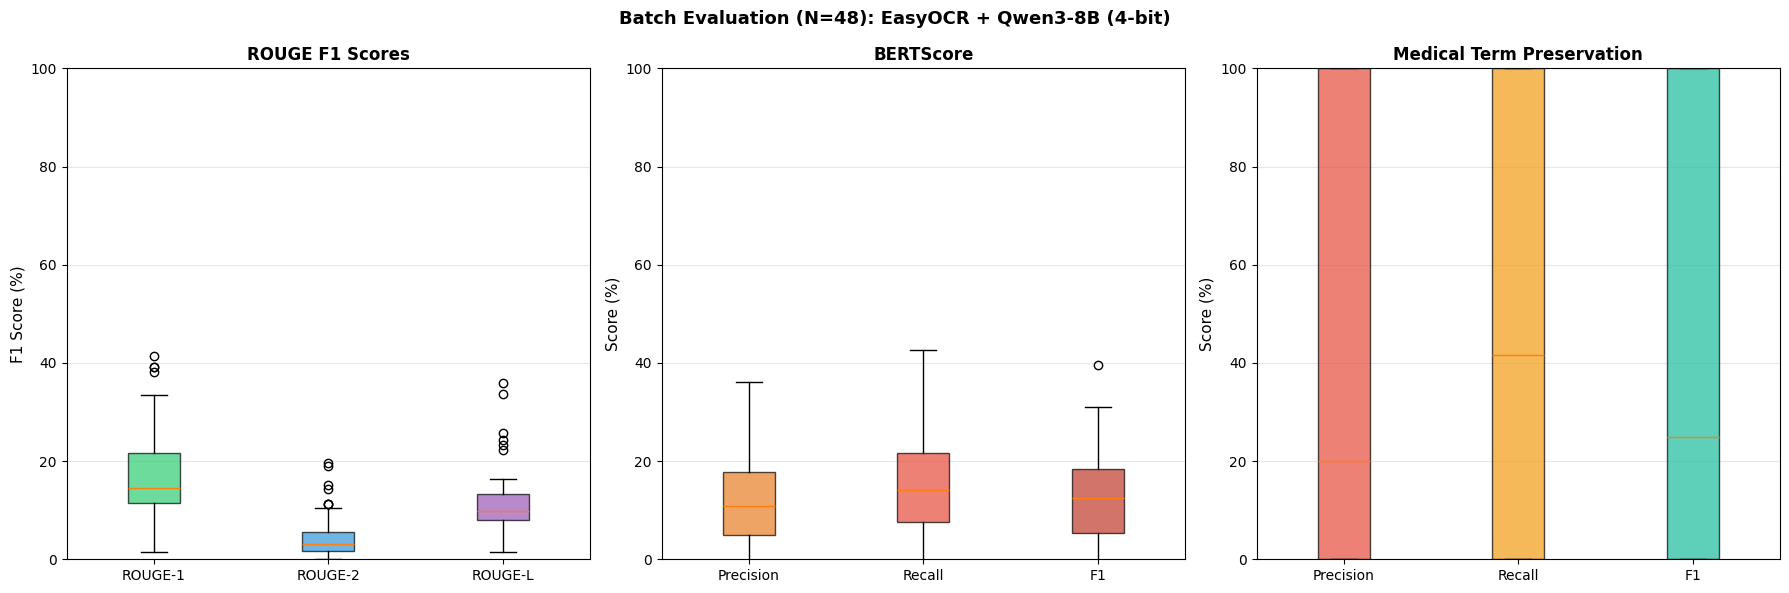

In [21]:
if batch_results:
    df = pd.DataFrame(batch_results)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f"Batch Evaluation (N={len(df)}): EasyOCR + Qwen3-8B (4-bit)", fontsize=13, fontweight='bold')

    # ── Panel 1: ROUGE F1 ────────────────────────────────────────────────────
    ax1 = axes[0]
    rouge_data = [df['rouge1_f1'], df['rouge2_f1'], df['rougeL_f1']]
    bp1 = ax1.boxplot(rouge_data, labels=['ROUGE-1', 'ROUGE-2', 'ROUGE-L'], patch_artist=True)
    for patch, color in zip(bp1['boxes'], ['#2ecc71', '#3498db', '#9b59b6']):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax1.set_ylabel('F1 Score (%)', fontsize=11)
    ax1.set_title('ROUGE F1 Scores', fontsize=12, fontweight='bold')
    ax1.set_ylim(0, 100); ax1.grid(axis='y', alpha=0.3)

    # ── Panel 2: BERTScore ───────────────────────────────────────────────────
    ax2 = axes[1]
    bert_data = [df['bertscore_precision'], df['bertscore_recall'], df['bertscore_f1']]
    bp2 = ax2.boxplot(bert_data, labels=['Precision', 'Recall', 'F1'], patch_artist=True)
    for patch, color in zip(bp2['boxes'], ['#e67e22', '#e74c3c', '#c0392b']):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax2.set_ylabel('Score (%)', fontsize=11)
    ax2.set_title('BERTScore', fontsize=12, fontweight='bold')
    ax2.set_ylim(0, 100); ax2.grid(axis='y', alpha=0.3)

    # ── Panel 3: Medical Term Preservation ───────────────────────────────────
    ax3 = axes[2]
    med_data = [df['medical_term_precision'], df['medical_term_recall'], df['medical_term_f1']]
    bp3 = ax3.boxplot(med_data, labels=['Precision', 'Recall', 'F1'], patch_artist=True)
    for patch, color in zip(bp3['boxes'], ['#e74c3c', '#f39c12', '#1abc9c']):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax3.set_ylabel('Score (%)', fontsize=11)
    ax3.set_title('Medical Term Preservation', fontsize=12, fontweight='bold')
    ax3.set_ylim(0, 100); ax3.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()


In [22]:
df.to_csv(PROJECT_ROOT / 'experiments/easyocr_piplines/results' / 'n48_easyocr_qwen3_8b_4bit_results.csv', index=False)